# Create hex grid of seed points - from centroid


In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
import shapely
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint, GeometryCollection

In [6]:
def hex_corner(centre: tuple[float, float], size: float, i: int, pointy: bool) -> tuple[float, float]:
    """Produces the ith corner of a regular hexagon.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A tuple of float coords representing the ith corner of a hexagon.
    """
    angle_deg: int
    if pointy:
        angle_deg = 60 * (i+1) - 30
    else:
        angle_deg = 60 * i
    angle_rad = math.pi / 180 * angle_deg
    # print(f"Point {i}: {angle_deg} degrees")
    return (centre[0] + size * math.cos(angle_rad),
            centre[1] + size * math.sin(angle_rad))

def hex_corner_flat(centre: tuple[float, float], size: float, i: int) -> tuple[float, float]:
    """Produces the ith corner of a flat-top regular hexagon.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A tuple representing the ith corner of a hexagon.
    """
    return hex_corner(centre, size, i, False)

def hex_corner_pointy(centre: tuple[float, float], size: float, i: int) -> tuple[float, float]:
    """Produces the ith corner of a pointy-top regular hexagon.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A float tuple.
    """
    return hex_corner(centre, size, i, True)

In [7]:
def get_hex_vertices(centre: tuple[float, float], size: float, pointy: bool) -> list[tuple[float, float]]:
    """Returns a list of hexagon corners as Shapely points.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A list of float tuples.
    """
    coords = []
    for i in range(0,6):
        coords.append(hex_corner(centre, size, i, pointy))
    return coords

In [8]:
# TODO: degrees are increasing counterclockwise,
#    I would rather have them increase clockwise

def create_hexagon(centre: tuple[float, float], size: float, pointy: bool, polygon: bool) -> shapely.Geometry:
    """Creates a regular hexagon as a Shapely polygon or curve.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
        as_polygon: Whether the hexagon should be a Shapely Polygon or LinearRing.
    
    Returns:
        A regular hexagon.
    """
    coords = get_hex_vertices(centre, size, pointy)
    if polygon:
        return Polygon(coords)
    else:
        return LinearRing(coords)

In [9]:
example_poly = create_hexagon((5.0, 5.0), 10.0, True, True)
example_line = create_hexagon((0.0, 0.0), 27.5, True, False)

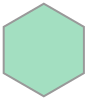

In [10]:
example_poly

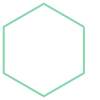

In [11]:
example_line

In [ ]:
# Code adapted from Red Blob Games
import collections

_Hex = collections.namedtuple("Hex", ["q", "r", "s"])

def Hex(q, r, s):
    assert not (round(q + r + s) != 0), "q + r + s must be 0"
    return _Hex(q, r, s)

hex_direction_vectors = [
    Hex(+1, 0, -1), Hex(+1, -1, 0), Hex(0, -1, +1), 
    Hex(-1, 0, +1), Hex(-1, +1, 0), Hex(0, +1, -1)
]

def hex_direction(direction):
    return hex_direction_vectors[direction]

def hex_add(hex, vec):
    return Hex(hex.q + vec.q, hex.r + vec.r, hex.s + vec.s)

def hex_neighbour(hex, direction):
    return hex_add(hex, hex_direction(direction))

hex_diagonal_vectors = [
    Hex(+2, -1, -1), Hex(+1, -2, +1), Hex(-1, -1, +2), 
    Hex(-2, +1, +1), Hex(-1, +2, -1), Hex(+1, +1, -2)
]

def hex_diagonal_neighbour(hex, direction):
    return hex_add(hex, hex_diagonal_vectors[direction])



For further inspiration, see:
1. https://www.redblobgames.com/grids/hexagons/implementation.html
2. https://github.com/RedFT/Hexy/tree/master
3. https://github.com/kompoth/geks/blob/main/geks/hexagon.py

My code needs to be able to:
1. Create a grid of hexagonal seed points within any shape, preferable building from the middle (centroid) of the shape
2. Access any of the seed points (corners of the hexagons)

For now, I can also just use the grid I made in `seed_points_experimental.ipynb` and ignore that it doesn't cover the whole rectangle shape (because it starts at x=0 and y=0). It won't matter until later anyway.